# Statistical Baseline

In this notebook we take the tools that we created till now and test them on a real ECG record. 

In [32]:
import numpy as np
import matplotlib.pyplot as plt

from m1_defect_anomaly_2026.preprocessing import preprocess, bandpass, FS
from m1_defect_anomaly_2026.beats import load_record_data, aggregate_to_beats
from m1_defect_anomaly_2026.detectors import zscore_detector


from pathlib import Path
import pandas as pd


REPO_ROOT=Path.cwd()
if REPO_ROOT.name=="notebooks":
    REPO_ROOT=REPO_ROOT.parent

DATA =str(REPO_ROOT/"data"/"raw")

RESULTS_DIR = Path("../results/statistical_baseline")
FIG_DIR = RESULTS_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)




## 1 - Compare the Raw and Filtered Signals

An ECG signal does not contain only heartbeats. It can also contain unwanted changes caused by breathing, body movement, or the recording equipment. For example, breathing and movement can make the signal slowly move up and down. The signal can also contain fast electrical noise. To reduce these unwanted changes, we use a band-pass filter between 0.5 Hz and 40 Hz. This filter helps us remove slow changes in the signal, remove high-frequency noise and keep the important heartbeat information.


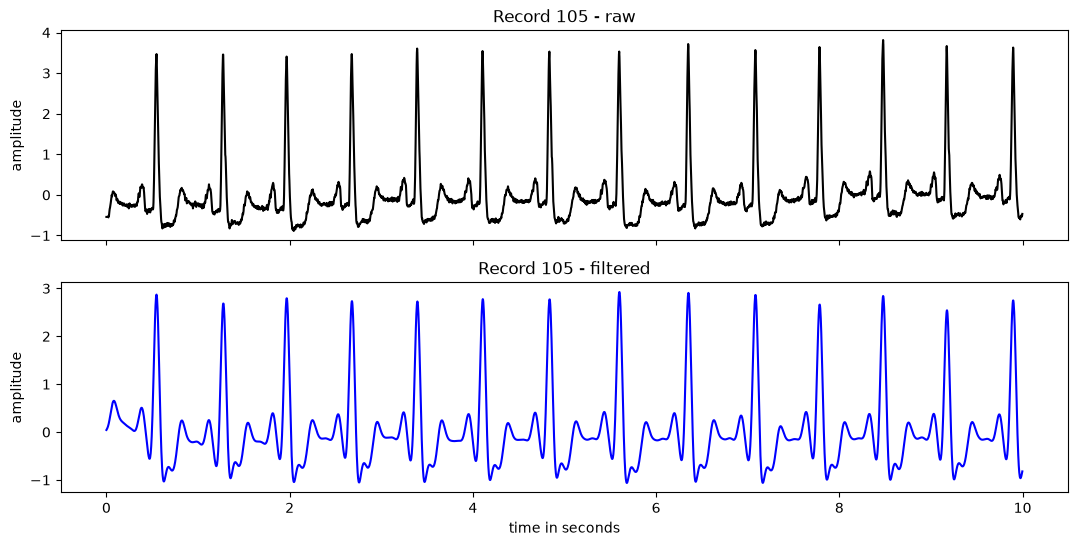

In [33]:
raw =load_record_data("105",data_dir=DATA,preprocess_method="none").signal
filtered=load_record_data("105",data_dir=DATA,preprocess_method="bandpass").signal

seconds = 10
n=seconds*FS
t=np.arange(n)/FS 

fig, axes = plt.subplots(2,1,figsize=(13,6), sharex=True)
axes[0].plot(t,raw[:n],"k")
axes[0].set_title("Record 105 - raw")
axes[0].set_ylabel("amplitude")
axes[1].plot(t,filtered[:n],"b")
axes[1].set_title("Record 105 - filtered")
axes[1].set_ylabel("amplitude")
axes[1].set_xlabel("time in seconds")

plt.savefig(FIG_DIR / "raw_vs_filtered.png")


Both panels show the same ten seconds of record 105. The raw signal has a noisy, slightly drifting baseline between beats but the filtered signal sits flat and clean. Every heartbeat stays in the same place and the filter only removed the noise and drift, it didn't touch the beats.

## 2 - Run the Z-score detector

We use the Z-score detector to check the data point by point and gives each one a score. If we have a high score that means that the point is far from its normal range, and if we have a low score that means that the point is close to normal. Here we aren't deciding what is normal and what isn't, we are just calculating the scores.

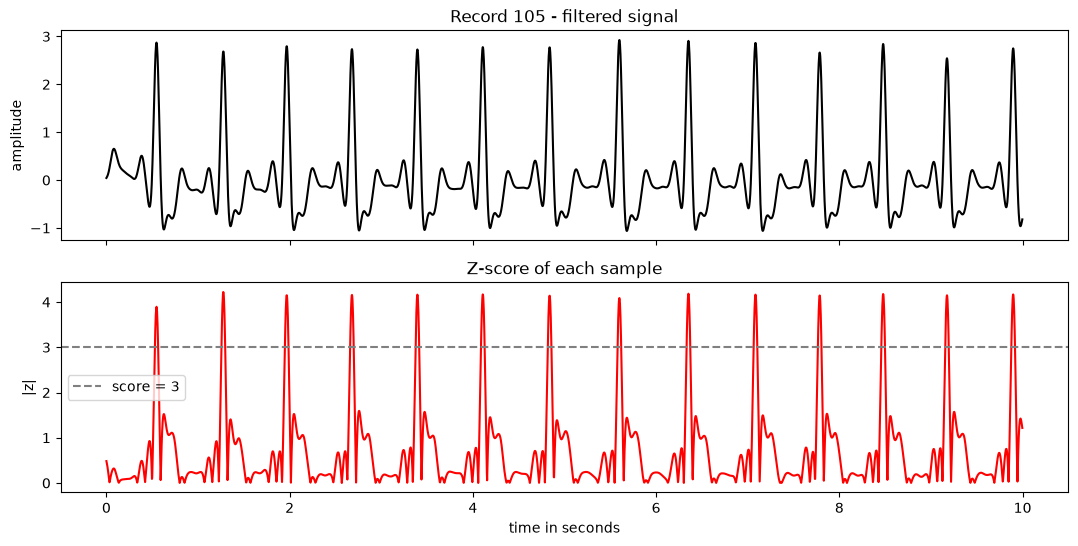

In [34]:
scores =zscore_detector(filtered,window=FS)

fig, axes=plt.subplots(2,1,figsize=(13,6),sharex=True)
axes[0].plot(t,filtered[:n],"k")
axes[0].set_title("Record 105 - filtered signal")
axes[0].set_ylabel("amplitude")
axes[1].plot(t,scores[:n],"r")
axes[1].axhline(3,linestyle="--",color="gray",label="score = 3")
axes[1].set_title("Z-score of each sample")
axes[1].set_ylabel("|z|")
axes[1].set_xlabel("time in seconds")
axes[1].legend()

plt.savefig(FIG_DIR / "zscore_one_second.png")

The red Z-score becomes high around every heartbeat and often crosses the threshold of 3. We used a window of one second. With this window, the detector reacts strongly to the sharp shape of each heartbeat. The R-peak is usually the sharpest part of a normal ECG heartbeat. Because it is very different from the samples around it, the detector gives it a high score.This means that the detector flags many normal heartbeats, even when they are not abnormal. With a one-second window, the Z-score detector behaves more like a heartbeat detector than an anomaly detector. This result shows that we need to test other methods, such as a wider window, heartbeat-shape comparison, or frequency-based features.

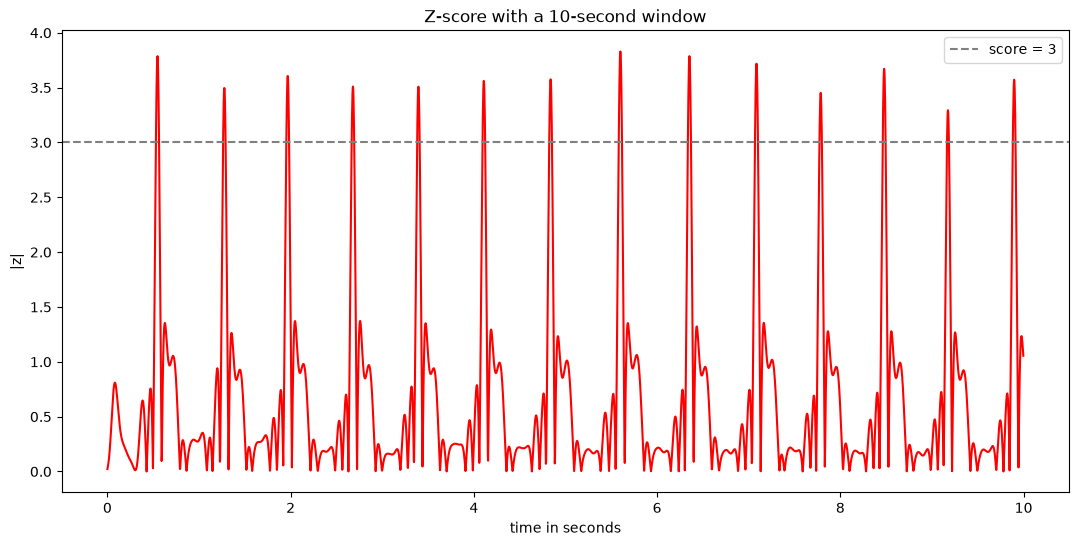

In [35]:
scores_wide =zscore_detector(filtered,window=10*FS) # 10 sec window

fig, axes=plt.subplots(1,1,figsize=(13,6),sharex=True)

axes.plot(t,scores_wide[:n],"r")
axes.axhline(3,linestyle="--",color="gray",label="score = 3")
axes.set_title("Z-score with a 10-second window")
axes.set_ylabel("|z|")
axes.set_xlabel("time in seconds")
axes.legend()

plt.savefig(FIG_DIR / "zscore_ten_seconds.png")

Making the window wider (10 seconds instead of 1) helped a little. But the detector still flags most normal heartbeats. This tells me the problem isn't the window size but the Z-score reacts to how sharp a beat is and normal heartbeats are sharp. So a wider window softens the issue but doesn't solve it. To really separate abnormal beats from normal ones, we need methods that compare each beat to a typical beat, or look at the frequency content.

To better separate normal and abnormal heartbeats, we need a method that studies the complete shape of each heartbeat or its frequency information.

## 3 - Filter reduces false positive?

We need to take a look at the false positive. In our case we use a dectector that could flag the sample that is anomalous when it is just part of a normal heartbeat.

In [36]:
scores_raw=zscore_detector(raw,window=FS)
scores_filtered=zscore_detector(filtered, window=FS)

threshold=3.0
flags_raw=(scores_raw >=threshold).sum()
flags_filtered=(scores_filtered>=threshold).sum()
total =len(raw)
print(f"raw signal:{flags_raw:6d} samples flagged ({100*flags_raw/total:.2f}%)")
print(f"filtered signal:{flags_filtered:6d} samples flagged ({100*flags_filtered/total:.2f}%)")
print(f"filtering changed the number of flags by ({flags_filtered-flags_raw:+d})")

percentage_change=((flags_filtered - flags_raw)/flags_raw)*100
print(f"Filtering changed the number of flags by {percentage_change:+.2f}%")


flag_results = pd.DataFrame([{
    "threshold": threshold,
    "total_samples": total,
    "flags_raw": int(flags_raw),
    "flags_raw_percent": 100 * flags_raw / total,
    "flags_filtered": int(flags_filtered),
    "flags_filtered_percent": 100 * flags_filtered / total,
    "difference": int(flags_filtered - flags_raw),
    "percentage_change": percentage_change
}])

flag_results.to_csv(RESULTS_DIR / "flag_results.csv",index=False)



raw signal: 25248 samples flagged (3.88%)
filtered signal: 30071 samples flagged (4.63%)
filtering changed the number of flags by (+4823)
Filtering changed the number of flags by +19.10%


The raw signal has 25,248 flagged samples, which represents 3.88% of the signal. The filtered signal has 30,071 flagged samples, which represents 4.63% of the signal.

After filtering, the detector flags 4,823 more samples. This is an increase of 19.10% compared with the raw signal. In this case, filtering does not reduce the number of flagged samples. It makes the Z-score detector more sensitive. One possible reason is that filtering removes noise and makes the heartbeat peaks sharper and clearer. Since the Z-score detector reacts strongly to sharp values, it may give higher scores around normal R-peaks.

However, these results only count flagged samples. They do not yet show the real number of false-positive heartbeats, because several flagged samples can belong to the same heartbeat.

## 4 - A closer look

The counts above are at the sample level. But our labels are per heartbeat, so it is more meaningful to ask: for each beat, how anomalous is it? "aggregate_to_beats" collapses the per-sample scores into one score per beat, by taking the highest score inside each beat's window. We can then compare those beat scores against the true labels the loader gives us.


In [37]:
rec = load_record_data("105",data_dir=DATA, preprocess_method="bandpass")

beat_scores = aggregate_to_beats(scores_filtered, rec.r_peaks)

# rec.y is the binary label: 0 = normal, 1 = anomaly
normal_scores = beat_scores[rec.y == 0]
anomaly_scores = beat_scores[rec.y == 1]

print(f"record 105: {rec.n_beats} beats, {int(rec.y.sum())} anomalies")
print(f"average score normal beats:  {normal_scores.mean():.2f}")
if len(anomaly_scores) > 0:
    print(f"average score anomaly beats: {anomaly_scores.mean():.2f}")
else:
    print("(record 105 has no anomalous beats in this labelling)")


beat_results = pd.DataFrame({
    "beat_number": range(len(beat_scores)),
    "label": rec.y,
    "score": beat_scores
})

beat_results["class"] = beat_results["label"].map({
    0: "normal",
    1: "anomaly"
})

beat_results.to_csv(RESULTS_DIR / "beat_scores.csv",index=False)

beat_results.head()

record 105: 2572 beats, 46 anomalies
average score normal beats:  3.82
average score anomaly beats: 3.21


,beat_number,label,score,class
0,0,0,3.895106,normal
1,1,0,4.220889,normal
2,2,0,4.148524,normal
3,3,0,4.156606,normal
4,4,0,4.163681,normal


The filtered signal contains 2,572 heartbeats, including 46 labelled anomalies. The average score for normal heartbeats is 3.82, while the average score for anomalous heartbeats is 3.21. Normal heartbeats receive a higher average score than anomalous heartbeats. This means that the Z-score detector does not clearly separate normal and abnormal heartbeats.

The detector is probably reacting to sharp ECG peaks, which are also present in normal heartbeats. Therefore, a high score cannot be directly interpreted as an abnormal heartbeat.

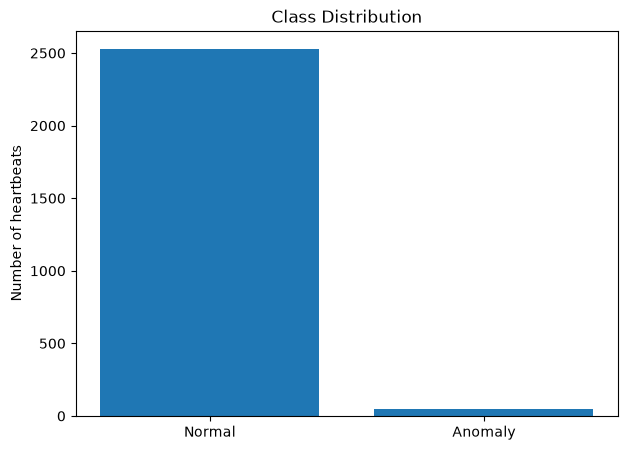

In [38]:
normal_count = len(normal_scores)
anomaly_count = len(anomaly_scores)

plt.figure(figsize=(7, 5))

plt.bar(
    ["Normal", "Anomaly"],
    [normal_count, anomaly_count]
)

plt.title("Class Distribution")
plt.ylabel("Number of heartbeats")

plt.savefig(FIG_DIR / "class_distribution.png")